# 03 – Classical Machine Learning Baselines

**Purpose:** Train, evaluate, and compare TF-IDF classical ML baseline models (Logistic Regression, Linear SVM, and Multinomial Naive Bayes) on the customer support dataset.

This notebook demonstrates:
1. Loading the preprocessed training and test splits.
2. Training each baseline model using standard scikit-learn Pipelines.
3. Running evaluation to collect key performance indicators: Accuracy, Precision, Recall, F1-score, Training Time, Inference Latency, and Model Size on disk.
4. Visualizing confusion matrices side-by-side.
5. Exporting predictions, reports, and metrics.

## 0. Environment Setup

Import baseline modules and register repository root path.

In [1]:
import json
import sys
from pathlib import Path

import IPython.display as display
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path().resolve().parent
if REPO_ROOT.name != "SupportAI" and (REPO_ROOT / "SupportAI").exists():
    REPO_ROOT = REPO_ROOT / "SupportAI"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Users\gunav\Downloads\SupportAI


## 1. Trigger Baseline Models Pipeline

We can trigger training and evaluation programmatically via the baseline CLI layer.

In [2]:
from src.models.baselines.cli import evaluate_baselines, train_baselines

# Run training on train split
train_baselines()

# Run evaluation on test split
evaluate_baselines()

[07/13/26 20:28:42] INFO     Initializing baseline training command...

                    INFO     All dataset splits cached locally under:                                              
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1. Loading...

                    INFO     Loading 'train' split from local cache:                                               
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\train.parquet

                    INFO     Loading 'val' split from local cache:                                                 
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\val.parquet

                    INFO     Loading 'test' split from local cache:                                                
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\test.parquet

...

                    INFO     Saving JSON artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\metrics.json

                    INFO     Saving CSV dataset to:                                                                
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\predictions.csv

                    INFO     Saving classification report to:                                                      
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\classification_report.txt

                    INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\figures\confusion_matrix.png

                    INFO     Baseline evaluation reports generated successfully.

## 2. Model Performance Comparison

Load the saved `metrics.json` file containing all metrics and display it as a comparison table.

In [3]:
metrics_path = REPO_ROOT / "outputs" / "metrics" / "metrics.json"
with open(metrics_path, encoding="utf-8") as f:
    metrics_dict = json.load(f)

# Convert to pandas DataFrame and transpose for clean view
df_comparison = pd.DataFrame(metrics_dict).T

# Reorder columns for readability
cols = [
    "accuracy",
    "f1_weighted",
    "precision_weighted",
    "recall_weighted",
    "training_time_seconds",
    "prediction_latency_ms_per_sample",
    "model_size_bytes",
]
df_comparison = df_comparison[cols]
df_comparison

,accuracy,f1_weighted,precision_weighted,recall_weighted,training_time_seconds,prediction_latency_ms_per_sample,model_size_bytes
logistic_regression,0.877880,0.877077,0.885093,0.877880,2.894583,0.018254,3278021.0
linear_svm,0.907066,0.906971,0.911023,0.907066,0.909691,0.015660,3277905.0
naive_bayes,0.847158,0.843201,0.856207,0.847158,0.172015,0.017205,6358554.0


## 3. Visualizing Metrics

Compare Model Accuracy and Prediction Latency side-by-side.

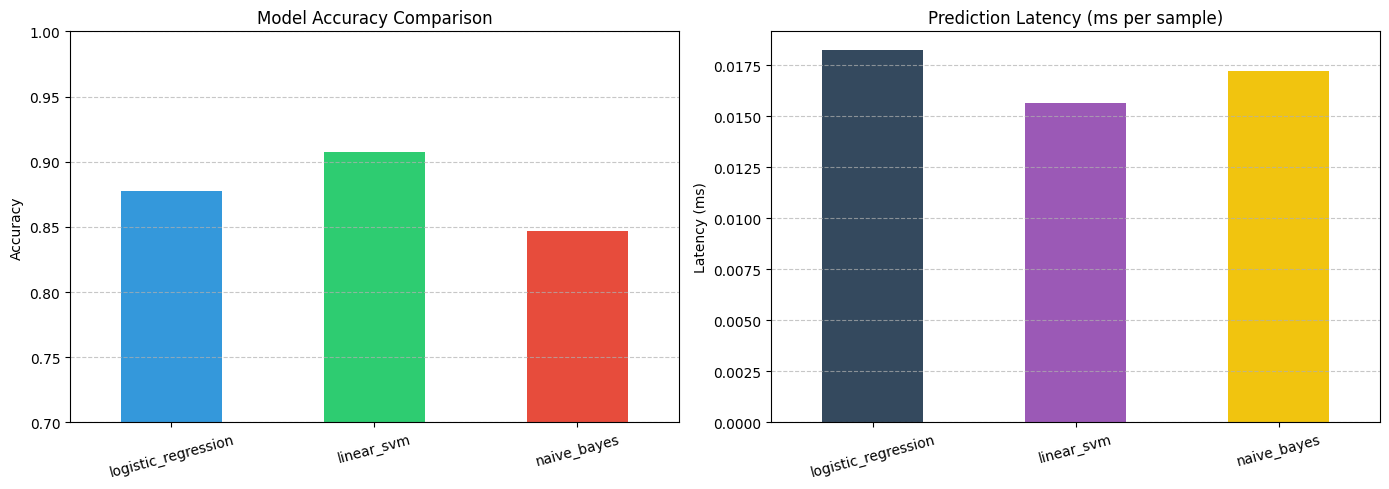

In [4]:
import sys

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Barplot
df_comparison["accuracy"].plot(kind="bar", ax=axes[0], color=["#3498db", "#2ecc71", "#e74c3c"])
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
axes[0].tick_params(axis="x", rotation=15)

# Latency Barplot
df_comparison["prediction_latency_ms_per_sample"].plot(kind="bar", ax=axes[1], color=["#34495e", "#9b59b6", "#f1c40f"])
axes[1].set_title("Prediction Latency (ms per sample)")
axes[1].set_ylabel("Latency (ms)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 4. Render Confusion Matrices

Display the generated side-by-side confusion matrix plot.

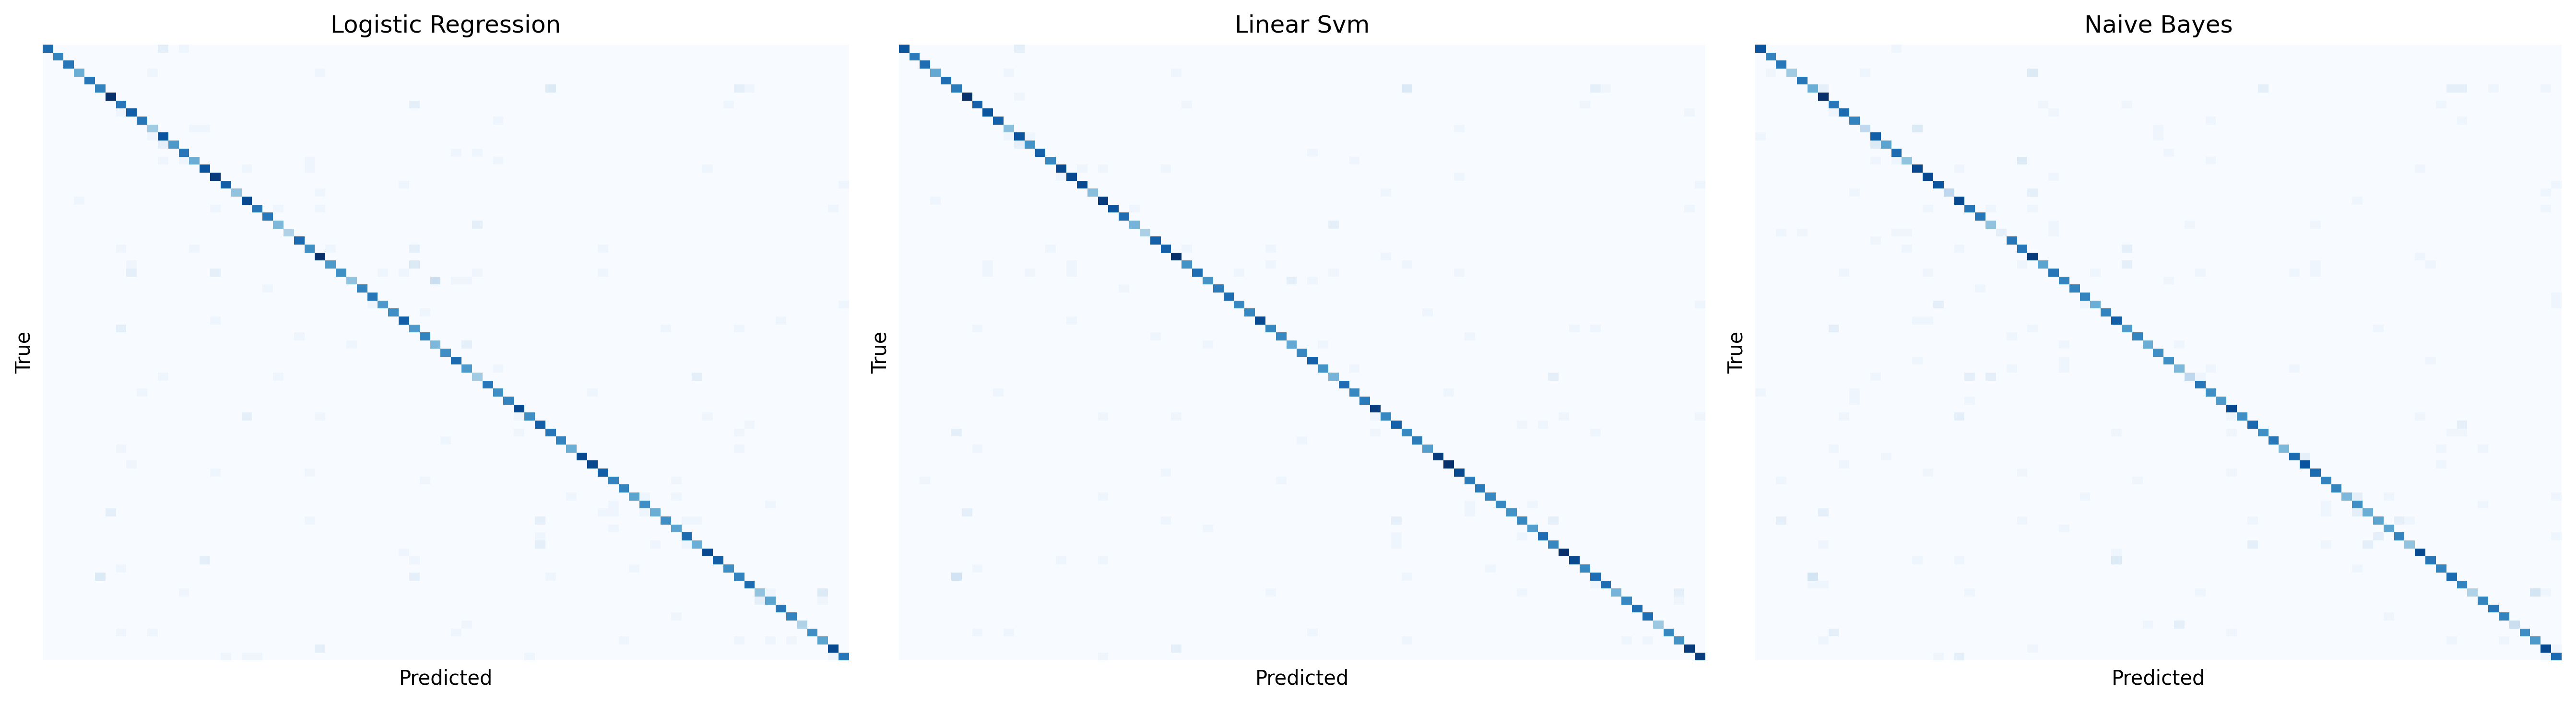

In [5]:
display.Image(filename=str(REPO_ROOT / "outputs" / "figures" / "confusion_matrix.png"))

## 5. Classification Reports

Print the classification report text file.

In [6]:
report_path = REPO_ROOT / "outputs" / "metrics" / "classification_report.txt"
with open(report_path, encoding="utf-8") as f:
    print(f.read())

MODEL: LOGISTIC_REGRESSION
                                                  precision    recall  f1-score   support

                                activate_my_card       1.00      0.85      0.92        20
                                       age_limit       1.00      1.00      1.00        15
                         apple_pay_or_google_pay       1.00      1.00      1.00        16
                                     atm_support       0.92      0.85      0.88        13
                                automatic_top_up       1.00      1.00      1.00        16
         balance_not_updated_after_bank_transfer       0.83      0.71      0.77        21
balance_not_updated_after_cheque_or_cash_deposit       0.92      1.00      0.96        22
                         beneficiary_not_allowed       0.70      0.84      0.76        19
                                 cancel_transfer       0.82      0.95      0.88        19
                            card_about_to_expire       0.94      0.94   

In [7]:
# Export Phase Manifest
from src.api.app import get_git_commit
from src.utils.artifacts import save_yaml

manifest = {
    "phase": "03_Baseline_Models",
    "metrics": metrics_dict,
    "git_commit": get_git_commit(),
}
save_yaml(manifest, REPO_ROOT / "outputs" / "manifests" / "phase_03_baselines.yaml")
print("YAML manifest saved successfully:")
print(manifest)


[07/13/26 20:28:48] INFO     Loading faiss with AVX2 support.

                    INFO     Could not load library with AVX2 support due to:                                      
                             ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")

                    INFO     Loading faiss.

                    INFO     Successfully loaded faiss.

[07/13/26 20:28:49] INFO     Saving YAML artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\manifests\phase_03_baselines.yaml

YAML manifest saved successfully:
{'phase': '03_Baseline_Models', 'metrics': {'logistic_regression': {'accuracy': 0.8778801843317973, 'precision_weighted': 0.8850925747825037, 'recall_weighted': 0.8778801843317973, 'f1_weighted': 0.877076814530713, 'training_time_seconds': 2.8945834999904037, 'prediction_latency_ms_per_sample': 0.018254070708702694, 'model_size_bytes': 3278021}, 'linear_svm': {'accuracy': 0.9070660522273426, 'precision_weighted': 0.911023421901031, 'recall_weighted': 0.9070660522273426, 'f1_weighted': 0.9069708213053176, 'training_time_seconds': 0.909690500004217, 'prediction_latency_ms_per_sample': 0.015659600756661864, 'model_size_bytes': 3277905}, 'naive_bayes': {'accuracy': 0.84715821812596, 'precision_weighted': 0.8562070120607993, 'recall_weighted': 0.84715821812596, 'f1_weighted': 0.8432005538472122, 'training_time_seconds': 0.1720154001377523, 'prediction_latency_ms_per_sample': 0.01720545317022024, 'model_size_bytes': 6358554}}, 'git_commit': 'ef9a0498221c5c43